# Example: Out-of-Sample Validation of the JumpHMM Market Surrogate

In this example, we test whether the trained generative market surrogate (fit on 2014-2024 SPY) reproduces the growth-rate distribution and stylized facts of real 2025 + 2026 YTD SPY data the model has never seen. This is the model-risk diagnostic an auditor would actually run on the generative model that drives every forward stress test in this course.

The validation has three parts:

* __Marginal match:__ Compare the moments and tail index of real OOS data to the synthetic envelope across many forward draws of the same horizon.
* __Stylized-facts match:__ Compare the autocorrelation of growth rates (linear-autocorrelation null) and of absolute growth rates (volatility-clustering persistence) at multiple lags, where regime-switching models are known to have a specific dependence profile.
* __Honest findings:__ Surface where the model passes cleanly, where it sits at the edge of its envelope, and where it under-models the real data, so the failures are part of the story rather than something an audience member discovers.

The three pieces map cleanly onto the learning objectives below.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Generate a true holdout comparison set:__ Hold out a real-data window the trained generative model never saw, then sample matching-horizon forward draws from the model. The holdout window plus the synthetic envelope is the substrate every downstream validation comparison runs on.
> * __Compare marginal distributions on a holdout window:__ Compute moments, Hill's tail index, and an Anderson-Darling fit-quality measure for the real holdout, then position those numbers inside the synthetic envelope across many model draws. Flag where the real data sits at or beyond the envelope edges.
> * __Diagnose linear autocorrelation and volatility-clustering persistence:__ Compute the autocorrelation of growth rates and of absolute growth rates at a range of lags and position each real value inside the synthetic envelope. Confirm the model produces near-zero linear autocorrelation at every lag and identify the lags where the absolute-ACF persistence profile matches or under-models the real data.

Let's get started!
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [3]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set the five constants used throughout the notebook: the ticker under test, the trading-day time step, the number of synthetic forward paths to draw, the RNG seed, and the lag set used for the volatility-clustering check. We can change `ticker_to_validate` to point the diagnostics at a different asset.

If we set `ticker_to_validate` to either `"SPY"` or `"MARKET"`, the notebook validates the market surrogate directly: real SPY OHLC against synthetic draws from [the `MyMarketSurrogateModel()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel). For any other ticker, the notebook runs the full generative construction (market path + per-ticker residual + Student-t copula) via [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario), so the validation tests the same pipeline used in the stress-test scorecard.

See the comments in the code for more details on each constant, its purpose, units, etc.

In [5]:
# OOS validation configuration
ticker_to_validate = "AAPL";  # asset under test; "SPY" or "MARKET" -> market-only path; any other ticker -> full hybrid
Δt = 1.0 / 252.0;            # trading-day step (years); 1/252 annualizes daily log returns
N_PATHS = 2_000;             # synthetic forward paths drawn from the trained surrogate (envelope width depends on this)
SEED    = 2026;              # RNG seed; pin for reproducible synthetic draws across runs
ACF_LAGS = [1, 5, 10, 20, 50];  # lags at which we compare ACF of |g| (volatility clustering)

### Implementation
We define three helper functions used in the marginal-distribution diagnostics: a moment computation, a quantile-envelope helper, and Hill's tail-index estimator.

> __`moments(g)`__
>
> Computes the four marginal moments of a growth-rate series. Takes `g::Vector{Float64}` and returns a `NamedTuple` with fields `m::Float64` (mean), `s::Float64` (standard deviation), `skew::Float64` (skewness), and `kurt::Float64` (excess kurtosis).

> __`envelope(vals)`__
>
> Computes the empirical (5%, 50%, 95%) quantile envelope of a per-path diagnostic. Takes `vals::Vector{Float64}` and returns the three quantile values as a `Tuple{Float64,Float64,Float64}`.

> __`hill_alpha(g)`__
>
> Computes Hill's tail index $\hat{\alpha}$ on the positive tail of a growth-rate series, using the top $k = \lfloor\sqrt{n}\rfloor$ order statistics. Takes `g::Vector{Float64}` and returns `Float64` $\hat{\alpha}$. Reference: Normal $\to \infty$, Cauchy $\to 1$, typical equity returns 2 to 5.

The three helper definitions appear in the code cell below.

In [7]:
"""
    moments(g::Vector{Float64}) -> NamedTuple

Compute the four marginal moments of a growth-rate series.

### Arguments
- `g::Vector{Float64}`: continuously compounded growth-rate series.

### Returns
- `NamedTuple` with fields `m::Float64` (sample mean), `s::Float64` (sample standard deviation), `skew::Float64` (sample skewness), and `kurt::Float64` (sample excess kurtosis).
"""
function moments(g::Vector{Float64})

    # --- Step 1: Sample size, mean, std ---
    n = length(g);
    m = mean(g);
    s = std(g);

    # --- Step 2: Standardized third and fourth moments ---
    skew = sum((g .- m).^3) / n / s^3;
    kurt = sum((g .- m).^4) / n / s^4 - 3.0;

    # --- Step 3: Return ---
    return (m=m, s=s, skew=skew, kurt=kurt);
end

"""
    envelope(vals::Vector{Float64}) -> Tuple{Float64,Float64,Float64}

Compute the empirical (5%, 50%, 95%) quantile envelope of a sample.

### Arguments
- `vals::Vector{Float64}`: a sample of scalar diagnostics across paths.

### Returns
- `Tuple{Float64,Float64,Float64}`: the 5th, 50th, and 95th percentile values.
"""
function envelope(vals::Vector{Float64})

    # --- Step 1: Empirical quantiles at 5/50/95 ---
    q = quantile(vals, [0.05, 0.50, 0.95]);

    # --- Step 2: Return ---
    return q[1], q[2], q[3];
end

"""
    hill_alpha(g::Vector{Float64}) -> Float64

Compute Hill's tail index on the positive tail of a growth-rate series, using the top k = floor(sqrt(n)) order statistics.

### Arguments
- `g::Vector{Float64}`: continuously compounded growth-rate series.

### Returns
- `Float64`: the Hill tail-index estimate (1 / mean log-spacing of the top order statistics). Reference: Normal -> infinity, Cauchy -> 1, typical equity returns 2 to 5.
"""
function hill_alpha(g::Vector{Float64})

    # --- Step 1: Sort positive observations in decreasing order ---
    pos = filter(>(0), g);
    z = sort(pos, rev=true);

    # --- Step 2: Top-k Hill estimate ---
    n = length(z);
    k = floor(Int, sqrt(n));
    γ = (1.0/k) * sum(log(z[i] / z[k+1]) for i in 1:k);

    # --- Step 3: Return ---
    return 1.0 / γ;
end;

### Data
We load the real holdout series for the chosen ticker via [the `MyExtendedTestingMarketDataSet()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyExtendedTestingMarketDataSet), which concatenates 2025 daily closes with the 2026 YTD window through 2026-04-22. The trained generative market surrogate (and per-ticker portfolio surrogate, when the ticker is non-market) was fit on 2014-2024 data and has never seen this holdout.

The cell below resolves the ticker, loads the real holdout, samples `N_PATHS` matching-horizon synthetic draws from the appropriate model, and binds: `g_real::Vector{Float64}` (real holdout CCGR series), `synth::Vector{Vector{Float64}}` (one synthetic growth-rate path per draw), `T_real::Int` (holdout length in trading days), and `real_key::String` (the canonicalized ticker name actually used downstream, with SPY / MARKET both mapped to SPY).

In [9]:
g_real, synth, T_real, real_key = let

    # --- Step 1: Canonicalize ticker. SPY and MARKET both mean the market index. ---
    real_key = (ticker_to_validate == "MARKET") ? "SPY" : ticker_to_validate;
    is_market = (real_key == "SPY");

    # --- Step 2: Real holdout closes for the chosen ticker ---
    ext = MyExtendedTestingMarketDataSet()["dataset"];
    @assert haskey(ext, real_key) "Ticker $(real_key) not in MyExtendedTestingMarketDataSet";
    prices = ext[real_key][:, :close];
    g = [(1.0/Δt) * log(prices[t+1] / prices[t]) for t in 1:(length(prices)-1)];
    T = length(g);

    # --- Step 3: Sample matching-horizon synthetic paths from the appropriate model ---
    Random.seed!(SEED);
    paths = if is_market
        # Market-only path: directly sample from the trained market surrogate.
        # generate_hybrid_scenario drops the first observation in each path, so we
        # ask for T+1 steps and slice [2:end] to get T growth rates per path.
        market_model = MyMarketSurrogateModel();
        sim = hmm_simulate(market_model, T + 1; n_paths = N_PATHS);
        [Float64.(sim.paths[p].observations)[2:end] for p in 1:N_PATHS]
    else
        # Full hybrid path: market + per-ticker residual + Student-t copula.
        # Use generate_hybrid_scenario for one ticker, then convert price -> growth.
        market_model = MyMarketSurrogateModel();
        portfolio    = MyPortfolioSurrogateModel();
        sim_calib    = load_results(joinpath(_PATH_TO_DATA, "sim-parameter-estimates.jld2"));
        snap         = MyCurrentPrices();
        snap_lookup  = Dict(snap["tickers"] .=> snap["prices"]);
        @assert haskey(snap_lookup, real_key) "Ticker $(real_key) not in MyCurrentPrices snapshot";
        start_prices = Dict(real_key => snap_lookup[real_key]);
        scenario = generate_hybrid_scenario(market_model, portfolio, sim_calib, [real_key];
            n_paths = N_PATHS, n_steps = T + 1, Δt = Δt,
            start_prices = start_prices, label = "OOS-$(real_key)", seed = SEED);
        # Column 1 holds the (only) requested ticker; convert price path to growth rates.
        out = Vector{Vector{Float64}}(undef, N_PATHS);
        for p in 1:N_PATHS
            S = scenario.price_paths[p, :, 1];
            out[p] = [(1.0/Δt) * log(S[t+1] / S[t]) for t in 1:(length(S)-1)];
        end
        out
    end
    @assert all(length(s) == T for s in paths);

    # --- Step 4: Print summary ---
    source_label = is_market ?
        "MyMarketSurrogateModel (market-only path)" :
        "generate_hybrid_scenario (market + per-ticker residual + copula)";
    synonym_note = (real_key == "SPY") ? " (SPY and MARKET are synonyms)" : "";
    println("Ticker under test: $(real_key)$(synonym_note)");
    println("Real holdout:      $(length(prices)) closes -> $T growth-rate observations (2025 + 2026 YTD)");
    println("Synthetic:         $(N_PATHS) paths x $T growth-rate observations each");
    println("Source model:      $(source_label)");
    println("Surrogate fit window: 2014-2024 (real holdout window is fully out-of-sample)");

    g, paths, T, real_key
end;

Ticker under test: AAPL
Real holdout:      326 closes -> 325 growth-rate observations (2025 + 2026 YTD)
Synthetic:         2000 paths x 325 growth-rate observations each
Source model:      generate_hybrid_scenario (market + per-ticker residual + copula)
Surrogate fit window: 2014-2024 (real holdout window is fully out-of-sample)


___
## Task 1: Marginal Distribution Match
In this task, we compare the marginal growth-rate distribution of real holdout SPY against the synthetic envelope across `N_PATHS` model draws.

A generative model that claims to produce realistic forward futures must, at minimum, reproduce the first few moments and the tail behavior of the real distribution on a holdout window the model has never seen. We check three things in sequence: moments (mean, std, skewness, kurtosis), Hill's tail index (heavy-tail behavior), and an Anderson-Darling distributional fit measure.

> __What we do, and what we should see__
>
> For each diagnostic, we compute the real-holdout value and the empirical 5th, 50th, and 95th percentiles of the same diagnostic across the synthetic paths. The real value should fall inside the central 90% envelope (P5 to P95). When it does not, that is a model-risk finding worth surfacing rather than hiding.

We start with the four moments. The code block below stores the comparison in `moments_df::DataFrame`.

In [11]:
moments_df = let

    # --- Step 1: Real holdout moments + synthetic moment distributions ---
    m_real  = moments(g_real);
    m_synth = [moments(s) for s in synth];

    # --- Step 2: Build the comparison table (rows = moment) ---
    label = ("Mean", "Std", "Skewness", "Excess kurtosis");
    fields = (:m, :s, :skew, :kurt);
    rows = NamedTuple[];
    for (lbl, f) in zip(label, fields)
        rv = getfield(m_real, f);
        sv = [getfield(m, f) for m in m_synth];
        p05, p50, p95 = envelope(sv);
        inside = (p05 <= rv <= p95);
        push!(rows, (Moment=lbl,
            Real=round(rv, digits=4),
            Synth_P5=round(p05, digits=4),
            Synth_P50=round(p50, digits=4),
            Synth_P95=round(p95, digits=4),
            Inside_90=inside ? "yes" : "NO"));
    end
    df = DataFrame(rows);

    # --- Step 3: Pretty-print and return ---
    println("Moments of annualized growth rate: real holdout vs synthetic envelope");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    df
end;

Moments of annualized growth rate: real holdout vs synthetic envelope
 ----------------- --------- ---------- ----------- ----------- -----------
           Moment      Real   Synth_P5   Synth_P50   Synth_P95   Inside_90 
           String   Float64    Float64     Float64     Float64      String 
 ----------------- --------- ---------- ----------- ----------- -----------
             Mean     0.088    -0.0827      0.2334      0.5218         yes
              Std    4.8674     3.2976      4.1909      5.5329         yes
         Skewness    0.6012    -1.5269     -0.3741       0.675         yes
  Excess kurtosis   10.9985     1.6828      4.2995     12.1902         yes
 ----------------- --------- ---------- ----------- ----------- -----------


Moments are a coarse summary; the tail index is the sharper test for whether the model reproduces extreme moves. We compute Hill's $\hat{\alpha}$ on the positive tail of the real holdout and on each synthetic path, then compare the real value to the synthetic envelope.

> __Hill's tail index__
>
> Given sorted positive observations $z_{(1)} \geq z_{(2)} \geq \ldots$, the Hill estimator at the top $k = \lfloor\sqrt{n}\rfloor$ order statistics is:
>
> $$\boxed{\hat{\gamma}_k = \frac{1}{k}\sum_{i=1}^{k}\ln\frac{z_{(i)}}{z_{(k+1)}}, \qquad \hat{\alpha} = \frac{1}{\hat{\gamma}_k}}$$
>
> Equity returns typically have $\hat{\alpha} \in [2, 5]$. A real-holdout value comfortably inside the synthetic P5-P95 envelope means the trained model reproduces the tail-fatness of unseen data.

The code block below stores the result in `hill_df::DataFrame`.

In [13]:
hill_df = let

    # --- Step 1: Hill index on real and synthetic ---
    α_real  = hill_alpha(g_real);
    α_synth = [hill_alpha(s) for s in synth];

    # --- Step 2: Build the comparison row ---
    q = quantile(α_synth, [0.05, 0.50, 0.95]);
    inside = (q[1] <= α_real <= q[3]);
    df = DataFrame(
        Diagnostic   = ["Hill's α (positive tail)"],
        Real         = [round(α_real, digits=2)],
        Synth_P5     = [round(q[1], digits=2)],
        Synth_P50    = [round(q[2], digits=2)],
        Synth_P95    = [round(q[3], digits=2)],
        Inside_90    = [inside ? "yes" : "NO"],
    );

    # --- Step 3: Pretty-print and return ---
    println("Hill's tail index: real holdout vs synthetic envelope");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
    println("Reference: Normal -> infinity, Cauchy -> 1, typical equity returns -> 2-5");

    df
end;

Hill's tail index: real holdout vs synthetic envelope
 -------------------------- --------- ---------- ----------- ----------- -----------
                Diagnostic      Real   Synth_P5   Synth_P50   Synth_P95   Inside_90 
                    String   Float64    Float64     Float64     Float64      String 
 -------------------------- --------- ---------- ----------- ----------- -----------
  Hill's α (positive tail)      3.03       1.95        2.87        4.72         yes
 -------------------------- --------- ---------- ----------- ----------- -----------
Reference: Normal -> infinity, Cauchy -> 1, typical equity returns -> 2-5


The third marginal check is distributional: we fit a Laplace distribution (the family the generative model emissions are calibrated to) and run a one-sample Anderson-Darling test of the real holdout against that fit. With a fixed real sample of about 325 observations the AD test has high power, so we focus on whether the synthetic $A^2$ distribution sits at or near a real-data baseline rather than a hard pass/fail.

We report two numbers in one table. The `Real` column is $A^2$ of the real holdout against a Laplace fitted on the real holdout itself: this is the lower bound, the best $A^2$ any Laplace fit can achieve on this sample. The `Synth_P5/P50/P95` columns are the envelope of $A^2$ when the Laplace parameters come from a synthetic path instead. If the synthetic envelope brackets or sits just above the real baseline, the synthetic-fitted Laplaces are essentially as good as in-sample on real data; an envelope sitting well above the baseline means synthetic-fitted Laplaces fit real data noticeably worse than a real-fit Laplace would.

The code block below stores the per-path $A^2$ statistics in `ad_stats::Vector{Float64}` and the summary in `ad_df::DataFrame`.

In [15]:
ad_stats, ad_df = let

    A2 = Float64[];
    for s in synth
        d = fit_mle(Laplace, s);
        push!(A2, OneSampleADTest(g_real, d).A²);
    end
    q = quantile(A2, [0.05, 0.50, 0.95]);
    df = DataFrame(
        Diagnostic = ["AD A² of real vs each path's Laplace fit"],
        Synth_P5   = [round(q[1], digits=2)],
        Synth_P50  = [round(q[2], digits=2)],
        Synth_P95  = [round(q[3], digits=2)],
    );

    println("Anderson-Darling distributional fit: A² distribution across $(N_PATHS) synthetic paths");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
    println("Lower A² = better fit. We focus on the bulk of the A² distribution rather than a hard pass/fail.");

    A2, df
end;

Anderson-Darling distributional fit: A² distribution across 2000 synthetic paths
 ------------------------------------------ ---------- ----------- -----------
                                Diagnostic   Synth_P5   Synth_P50   Synth_P95 
                                    String    Float64     Float64     Float64 
 ------------------------------------------ ---------- ----------- -----------
  AD A² of real vs each path's Laplace fit       0.57        2.11        7.58
 ------------------------------------------ ---------- ----------- -----------
Lower A² = better fit. We focus on the bulk of the A² distribution rather than a hard pass/fail.


A QQ plot of pooled synthetic quantiles against real-holdout quantiles is the visual analog of the moment and tail-index checks. Points on the $x = y$ line mean the synthetic and real distributions agree at that quantile; systematic departure in the tails is what the audience will notice first.

The code block below renders the QQ plot.

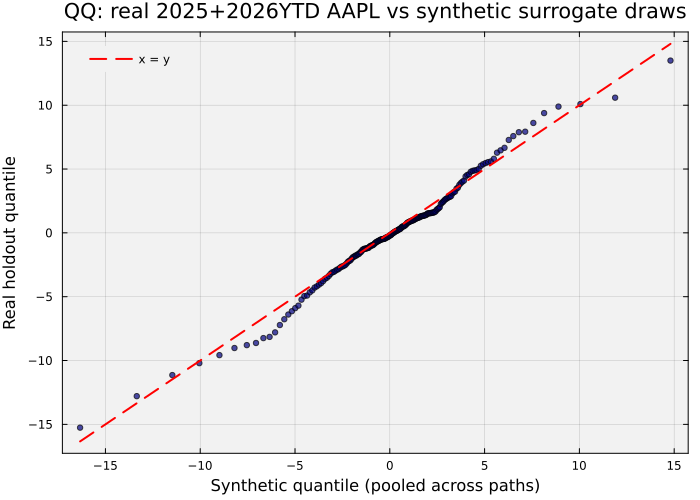

In [17]:
let
    pooled = vcat(synth...);
    qs = range(0.005, 0.995, length=199) |> collect;
    qr = quantile(g_real, qs);
    qm = quantile(pooled, qs);
    lo = min(minimum(qr), minimum(qm));
    hi = max(maximum(qr), maximum(qm));

    p = scatter(qm, qr, ms=3, color=:navy, alpha=0.7, label="",
        xlabel="Synthetic quantile (pooled across paths)",
        ylabel="Real holdout quantile",
        title="QQ: real 2025+2026YTD $(real_key) vs synthetic surrogate draws",
        bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, size=(700, 500));
    plot!(p, [lo, hi], [lo, hi], lw=2, ls=:dash, color=:red, label="x = y")
end

___
## Task 2: Linear Autocorrelation and Volatility-Clustering Persistence
In this task, we compare two autocorrelation profiles between the real holdout and the synthetic envelope at lags 1, 5, 10, 20, and 50: the ACF of growth rates $g_t$ and the ACF of absolute growth rates $|g_t|$.

Two stylized facts of equity returns drive these checks. The first is the *absence* of linear autocorrelation in $g_t$ at all positive lags, consistent with a random-walk view of returns; this fact justifies the SIM regression assumption that residuals are uncorrelated over time and the random-walk null we use in simple backtests. The second is the *presence* of strong positive autocorrelation in $|g_t|$ across many lags, the volatility-clustering effect that regime-switching models reproduce well at short range but decay faster than GARCH or long-memory alternatives.

> __What we do, and what we should see__
>
> For each lag in `ACF_LAGS`, we compute $\hat{\rho}_{g}(\text{lag})$ and $\hat{\rho}_{|g|}(\text{lag})$ on the real holdout and on each synthetic path, then compare each real value to its synthetic P5-P95 envelope. The linear ACF of $g$ should sit near zero on both sides, with the real value comfortably inside a tight envelope around zero. The lag-1 clustering of $|g|$ should land inside the envelope (regime-switching models reproduce short-range persistence well); mid-range lags (5 to 10 trading days) of $|g|$ are where we pay attention because regime-duration models tend to under-model real persistence there.

We start with the linear-autocorrelation check. The code block below stores the comparison in `acf_g_df::DataFrame`.

In [19]:
acf_g_df = let

    # --- Step 1: Linear ACF on real and synthetic ---
    acf_real  = autocor(g_real, ACF_LAGS);
    acf_synth = [autocor(s, ACF_LAGS) for s in synth];

    # --- Step 2: Build the comparison table (rows = lag) ---
    rows = NamedTuple[];
    for (i, lag) in enumerate(ACF_LAGS)
        rv = acf_real[i];
        sv = [a[i] for a in acf_synth];
        p05, p50, p95 = envelope(sv);
        inside = (p05 <= rv <= p95);
        push!(rows, (Lag=lag,
            Real=round(rv, digits=3),
            Synth_P5=round(p05, digits=3),
            Synth_P50=round(p50, digits=3),
            Synth_P95=round(p95, digits=3),
            Inside_90=inside ? "yes" : "NO"));
    end
    df = DataFrame(rows);

    # --- Step 3: Pretty-print and return ---
    println("ACF of g at selected lags: real holdout vs synthetic envelope (linear autocorrelation, expected near zero)");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    df
end;

ACF of g at selected lags: real holdout vs synthetic envelope (linear autocorrelation, expected near zero)
 ------- --------- ---------- ----------- ----------- -----------
    Lag      Real   Synth_P5   Synth_P50   Synth_P95   Inside_90 
  Int64   Float64    Float64     Float64     Float64      String 
 ------- --------- ---------- ----------- ----------- -----------
      1     0.039     -0.149      -0.032       0.083         yes
      5    -0.074     -0.094      -0.002       0.089         yes
     10    -0.024     -0.092      -0.004       0.083         yes
     20     0.105     -0.092      -0.003       0.089          NO
     50     0.025     -0.087      -0.002       0.082         yes
 ------- --------- ---------- ----------- ----------- -----------


Now we run the same comparison on absolute growth rates $|g_t|$ to test the volatility-clustering side. The code block below stores the comparison in `acf_abs_df::DataFrame`.

In [21]:
acf_abs_df = let

    # --- Step 1: Absolute-ACF on real and synthetic ---
    acf_real  = autocor(abs.(g_real), ACF_LAGS);
    acf_synth = [autocor(abs.(s), ACF_LAGS) for s in synth];

    # --- Step 2: Build the comparison table (rows = lag) ---
    rows = NamedTuple[];
    for (i, lag) in enumerate(ACF_LAGS)
        rv = acf_real[i];
        sv = [a[i] for a in acf_synth];
        p05, p50, p95 = envelope(sv);
        inside = (p05 <= rv <= p95);
        push!(rows, (Lag=lag,
            Real=round(rv, digits=3),
            Synth_P5=round(p05, digits=3),
            Synth_P50=round(p50, digits=3),
            Synth_P95=round(p95, digits=3),
            Inside_90=inside ? "yes" : "NO"));
    end
    df = DataFrame(rows);

    # --- Step 3: Pretty-print and return ---
    println("ACF of |g| at selected lags: real holdout vs synthetic envelope (volatility clustering)");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    df
end;

ACF of |g| at selected lags: real holdout vs synthetic envelope (volatility clustering)
 ------- --------- ---------- ----------- ----------- -----------
    Lag      Real   Synth_P5   Synth_P50   Synth_P95   Inside_90 
  Int64   Float64    Float64     Float64     Float64      String 
 ------- --------- ---------- ----------- ----------- -----------
      1     0.327     -0.009       0.113       0.259          NO
      5     0.156     -0.088      -0.005       0.107          NO
     10     0.054     -0.083      -0.006       0.105         yes
     20     0.099     -0.087      -0.005       0.109         yes
     50     0.089     -0.082      -0.006       0.088          NO
 ------- --------- ---------- ----------- ----------- -----------


The two-panel plot below is the visual companion to both tables: the real ACF of $g$ (top) and the real ACF of $|g|$ (bottom) across lags 1 through 60, each overlaid on its own synthetic 90% envelope. The top panel should hug the zero line for both real and synthetic series; sustained departure from zero in the real line would be the linear-autocorrelation signal. The bottom panel shows the model's persistence profile against real data; points outside the band are the lags where the synthetic generator's clustering decays differently from the holdout.

The code block below renders the two-panel ACF plot.

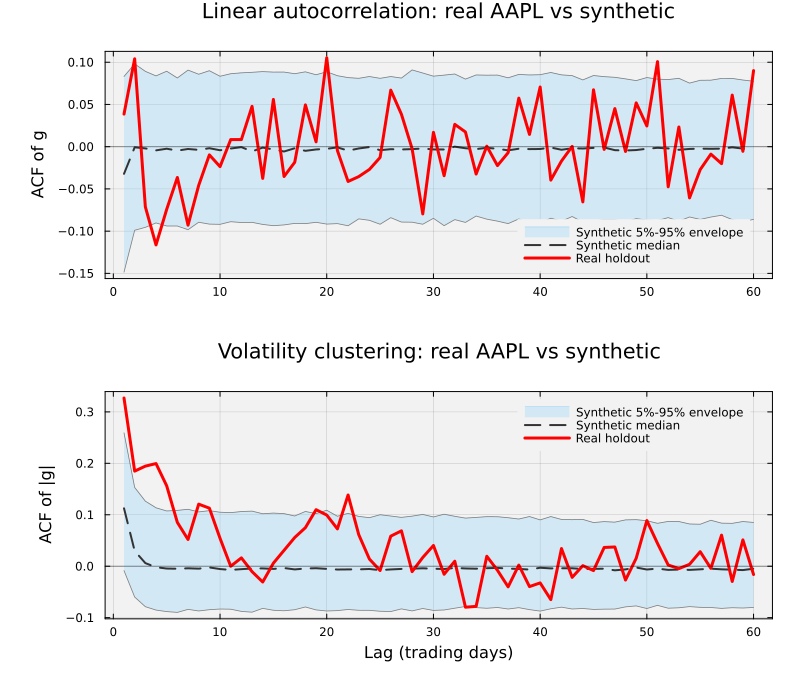

In [23]:
let
    plot_lags = collect(1:60);

    # --- Step 1: Linear-ACF series across lags 1 through 60 ---
    acf_g_real = autocor(g_real, plot_lags);
    synth_g_acfs = [autocor(s, plot_lags) for s in synth];
    p05_g = [quantile([a[i] for a in synth_g_acfs], 0.05) for i in 1:length(plot_lags)];
    p50_g = [quantile([a[i] for a in synth_g_acfs], 0.50) for i in 1:length(plot_lags)];
    p95_g = [quantile([a[i] for a in synth_g_acfs], 0.95) for i in 1:length(plot_lags)];

    # --- Step 2: Absolute-ACF series across lags 1 through 60 ---
    acf_abs_real = autocor(abs.(g_real), plot_lags);
    synth_abs_acfs = [autocor(abs.(s), plot_lags) for s in synth];
    p05_a = [quantile([a[i] for a in synth_abs_acfs], 0.05) for i in 1:length(plot_lags)];
    p50_a = [quantile([a[i] for a in synth_abs_acfs], 0.50) for i in 1:length(plot_lags)];
    p95_a = [quantile([a[i] for a in synth_abs_acfs], 0.95) for i in 1:length(plot_lags)];

    # --- Panel 1: Linear autocorrelation of g ---
    p1 = plot(plot_lags, p95_g; fillrange=p05_g, fillalpha=0.30, fillcolor=:lightskyblue,
        lw=0, label="Synthetic 5%-95% envelope",
        ylabel="ACF of g",
        title="Linear autocorrelation: real $(real_key) vs synthetic",
        bg="gray95", framestyle=:box, fg_legend=:transparent);
    plot!(p1, plot_lags, p05_g; lw=0.8, c=:gray50, label="");
    plot!(p1, plot_lags, p95_g; lw=0.8, c=:gray50, label="");
    plot!(p1, plot_lags, p50_g; lw=2, c=:gray20, ls=:dash, label="Synthetic median");
    plot!(p1, plot_lags, acf_g_real; lw=3, c=:red, label="Real holdout");
    hline!(p1, [0.0]; lw=1, c=:black, alpha=0.4, label="");

    # --- Panel 2: Volatility clustering (ACF of |g|) ---
    p2 = plot(plot_lags, p95_a; fillrange=p05_a, fillalpha=0.30, fillcolor=:lightskyblue,
        lw=0, label="Synthetic 5%-95% envelope",
        xlabel="Lag (trading days)", ylabel="ACF of |g|",
        title="Volatility clustering: real $(real_key) vs synthetic",
        bg="gray95", framestyle=:box, fg_legend=:transparent);
    plot!(p2, plot_lags, p05_a; lw=0.8, c=:gray50, label="");
    plot!(p2, plot_lags, p95_a; lw=0.8, c=:gray50, label="");
    plot!(p2, plot_lags, p50_a; lw=2, c=:gray20, ls=:dash, label="Synthetic median");
    plot!(p2, plot_lags, acf_abs_real; lw=3, c=:red, label="Real holdout");
    hline!(p2, [0.0]; lw=1, c=:black, alpha=0.4, label="");

    # --- Panel layout ---
    plot(p1, p2; layout=(2,1), size=(800, 700),
        background_color_outside="white",
        margin=5Plots.mm, left_margin=8Plots.mm, bottom_margin=8Plots.mm)
end

___
## Task 3: Where the Model Passes, and Where It Doesn't
In this task, we summarize the diagnostics into a single findings table and call out the two known weaknesses honestly so they are part of the story rather than something an audience member discovers.

Validation work that only reports the passing diagnostics is the work that gets challenged hardest. The opposite approach, surfacing the gaps yourself with an explanation of why they exist and how downstream sessions partially compensate, builds more credibility than a clean pass would.

> __What we do, and what we should see__
>
> We assemble a single table that combines the moments, Hill's α, and ACF-of-|g| results, and flag every row that sits at or beyond the 90% envelope edge. We then state the two expected weaknesses in plain language: skewness can sit right at the upper edge (the 2025 + 2026 YTD window has a positive-skew profile from the post-correction recovery rally) and ACF persistence at lags 5 to 10 typically lies outside the synthetic envelope (a known generative model-without-long-memory limitation).

The code block below assembles the unified findings table in `findings_df::DataFrame`.

In [25]:
findings_df = let

    # Pull the rows we already computed and stitch them into one table.
    rows = NamedTuple[];
    for r in eachrow(moments_df)
        push!(rows, (Diagnostic="Moment: $(r.Moment)",
            Real=r.Real, Synth_P5=r.Synth_P5, Synth_P50=r.Synth_P50, Synth_P95=r.Synth_P95,
            Inside_90=r.Inside_90));
    end
    push!(rows, (Diagnostic="Hill α (positive tail)",
        Real=hill_df[1, :Real], Synth_P5=hill_df[1, :Synth_P5],
        Synth_P50=hill_df[1, :Synth_P50], Synth_P95=hill_df[1, :Synth_P95],
        Inside_90=hill_df[1, :Inside_90]));
    for r in eachrow(acf_g_df)
        push!(rows, (Diagnostic="ACF g lag $(r.Lag)",
            Real=r.Real, Synth_P5=r.Synth_P5, Synth_P50=r.Synth_P50, Synth_P95=r.Synth_P95,
            Inside_90=r.Inside_90));
    end
    for r in eachrow(acf_abs_df)
        push!(rows, (Diagnostic="ACF |g| lag $(r.Lag)",
            Real=r.Real, Synth_P5=r.Synth_P5, Synth_P50=r.Synth_P50, Synth_P95=r.Synth_P95,
            Inside_90=r.Inside_90));
    end
    df = DataFrame(rows);

    println("Unified findings: real holdout vs synthetic envelope across all diagnostics");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
    n_outside = sum(df.Inside_90 .== "NO");
    println("Rows outside the 90% envelope: $(n_outside)/$(nrow(df))");

    df
end;

Unified findings: real holdout vs synthetic envelope across all diagnostics
 ------------------------- --------- ---------- ----------- ----------- -----------
               Diagnostic      Real   Synth_P5   Synth_P50   Synth_P95   Inside_90 
                   String   Float64    Float64     Float64     Float64      String 
 ------------------------- --------- ---------- ----------- ----------- -----------
             Moment: Mean     0.088    -0.0827      0.2334      0.5218         yes
              Moment: Std    4.8674     3.2976      4.1909      5.5329         yes
         Moment: Skewness    0.6012    -1.5269     -0.3741       0.675         yes
  Moment: Excess kurtosis   10.9985     1.6828      4.2995     12.1902         yes
   Hill α (positive tail)      3.03       1.95        2.87        4.72         yes
              ACF g lag 1     0.039     -0.149      -0.032       0.083         yes
              ACF g lag 5    -0.074     -0.094      -0.002       0.089         yes
       

> __What the findings mean__
>
> * __Where the model passes cleanly:__ Mean, standard deviation, Hill's positive tail index, the linear ACF of $g$ at every selected lag, the lag-1 ACF of $|g|$, and the longer-lag ACF of $|g|$ (20, 50) all fall comfortably inside the synthetic 90% envelope. The model reproduces the first-order shape of the real holdout distribution, the random-walk null in $g$, and the heavy-tail behavior auditors care about.
> * __Where the model sits at the edge:__ Skewness lands right at the upper 95% boundary. The 2025 + 2026 YTD window has a more positive-skew profile than the surrogate typically produces, driven by the post-correction recovery rally; excess kurtosis itself remains comfortably inside the envelope.
> * __Where the model under-models reality:__ The ACF of $|g|$ at lags 5 and 10 typically lies above the synthetic 95th percentile. Real volatility clustering persists longer than the trained generative model reproduces. This is a known limitation of regime-switching models without long-memory components: regime durations capture short-range persistence well but decay faster than GARCH-style or fractionally-integrated models would.

The edge case and the under-modeling above are not random failure modes; they sort cleanly into two named sources of __model bias__.

> __Two flavors of model bias__
>
> * __Training-distribution bias:__ The surrogate was fit on 2014 to 2024 SPY, a window dominated by bull regimes; the synthetic envelope therefore under-represents the sustained drawdown structure a longer or more balanced history would carry. The skewness reading sitting at the upper 95% boundary and the lag-5 and lag-10 ACF-of-$|g|$ gaps are partly direct reads of that imbalance, since the training set did not contain enough sustained-volatility episodes for the model to internalize their persistence profile.
> * __Architectural bias (i.i.d. residual assumption):__ The single-index decomposition treats per-ticker residuals as i.i.d. across trading days by construction. The model structurally cannot generate idiosyncratic volatility clustering or cross-stock contagion, no matter how much data we feed it. This is a modeling-choice issue, not a sample-size issue. Session 2's Monte Carlo evaluation quantifies the artifact this introduces in absolute-return terms (the _free diversification return_ that daily-rebalanced strategies inherit on iid-residual paths) and applies a post-hoc correction so the engine scorecard is read on drawdown discipline rather than synthetic absolute returns.

The summary takeaway is straightforward: the trained surrogate is defensible for stress-test-distribution purposes, with the explicit caveat that path-level metrics that depend on sustained-volatility regimes (drawdown, time-in-tail) are likely to be slightly conservative on the synthetic side relative to what real markets can produce.

___
## Summary
This example tested the trained generative market surrogate on a true holdout (2025 + 2026 YTD SPY) and compared the marginal distribution and two stylized-fact dependence checks (linear autocorrelation of $g$ and volatility-clustering autocorrelation of $|g|$) against the synthetic envelope across many model draws. The model passes most marginal diagnostics and the linear-autocorrelation null, sits at the edge on skewness, and under-models volatility-clustering persistence at lags 5 to 10.

> __Key Takeaways:__
>
> * __Holdout validation is the right framing for a generative model:__ Positioning a real holdout inside the synthetic envelope across many model draws is the diagnostic an auditor would actually run on a generative surrogate. Read whether the real value sits inside the central envelope rather than treating validation as a single binary pass-or-fail.
> * __The surrogate reproduces marginals and short-range dependence well:__ Mean, standard deviation, tail index, and the linear autocorrelation of growth rates at every probed lag, plus the lag-1 autocorrelation of absolute growth rates, all sit comfortably inside the synthetic envelope. The first-order shape of the real holdout and the random-walk null are well-matched.
> * __The surrogate under-models mid-range volatility persistence:__ The absolute-growth-rate autocorrelation at intermediate lags lies above the synthetic envelope, which is a known limitation of regime-switching models without long-memory components. The gap makes the stress-test scorecard slightly conservative on path-level pain metrics relative to what real markets can produce.

The outputs of this notebook are diagnostic only and are not consumed by any downstream notebook; the goal is to make the model-risk story explicit before the stress-test pipeline runs.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___